In [2]:
# To Do: AI Use Disclaimer

In [3]:
# %pip install polars
# %pip install duckdb

In [4]:
import pandas as pd
import duckdb
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import re
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

## Loading the Data - the 5 Products

In [5]:
# Load parquet into lazy dataframe and display the head
PARQUET_PATH = '../data/processed/consumer_banking_complaints.parquet'
df = pl.scan_parquet(PARQUET_PATH)

print(f"Total number of records: {df.select(pl.len()).collect()}")
df.head(5).collect()

Total number of records: shape: (1, 1)
┌─────────┐
│ len     │
│ ---     │
│ u32     │
╞═════════╡
│ 1134035 │
└─────────┘


Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
date,str,str,str,str,str,str,str,str,str,str,str,str,date,str,bool,str,i64
2019-12-26,"""Credit card or prepaid card""","""General-purpose credit card or…","""Advertising and marketing, inc…","""Confusing or misleading advert…",null,null,"""CAPITAL ONE FINANCIAL CORPORAT…","""CA""","""94025""",null,"""Consent not provided""","""Web""",2019-12-26,"""Closed with explanation""",true,"""N/A""",3477549
2019-12-20,"""Checking or savings account""","""Other banking product or servi…","""Managing an account""","""Funds not handled or disbursed…",null,"""Company has responded to the c…","""WELLS FARGO & COMPANY""","""FL""","""33064""",null,"""N/A""","""Referral""",2019-12-23,"""Closed with explanation""",true,"""N/A""",3475858
2019-11-18,"""Credit card or prepaid card""","""General-purpose credit card or…","""Problem with a purchase shown …","""Credit card company isn't reso…","""XXXX claimed they delivered a …",null,"""DISCOVER BANK""","""MA""","""021XX""",null,"""Consent provided""","""Web""",2019-11-18,"""Closed with explanation""",true,"""N/A""",3442136
2020-06-05,"""Checking or savings account""","""Checking account""","""Managing an account""","""Problem using a debit or ATM c…",null,"""Company has responded to the c…","""CITIBANK, N.A.""","""NY""","""10466""",null,"""Consent not provided""","""Web""",2020-06-05,"""Closed with explanation""",true,"""N/A""",3684669
2024-01-16,"""Credit card""","""General-purpose credit card or…","""Other features, terms, or prob…","""Add-on products and services""",null,"""Company has responded to the c…","""WELLS FARGO & COMPANY""","""TX""","""76179""",null,"""Consent not provided""","""Web""",2024-01-16,"""Closed with monetary relief""",true,"""N/A""",8161600


In [6]:
# Check date range of the current data
df.select(
    pl.col('Date received').min().alias('min_date'),
    pl.col('Date received').max().alias('max_date')
).collect()

min_date,max_date
date,date
2016-01-01,2026-05-30


In [7]:
# View number of complaints by product
duckdb.sql(f"""
    SELECT
        Product,
        COUNT(*) AS complaints
    FROM '{PARQUET_PATH}'
    GROUP BY Product
    ORDER BY complaints DESC
""")

┌─────────────────────────────┬────────────┐
│           Product           │ complaints │
│           varchar           │   int64    │
├─────────────────────────────┼────────────┤
│ Checking or savings account │     368590 │
│ Mortgage                    │     275786 │
│ Credit card                 │     254494 │
│ Credit card or prepaid card │     206364 │
│ Bank account or service     │      28801 │
└─────────────────────────────┴────────────┘

## Timely Response Analysis

In [8]:
# Check class balance for Timely Response (narrative not null)
timely_balance = duckdb.sql(f"""
    SELECT
        "Timely response?",
        COUNT(*) AS complaints,
        ROUND(
            100.0 * COUNT(*) / SUM(COUNT(*)) OVER (),
            2
        ) AS pct_of_total
    FROM '{PARQUET_PATH}'
    WHERE "Consumer complaint narrative" IS NOT NULL
    GROUP BY "Timely response?"
    ORDER BY complaints DESC
""")

timely_balance

┌──────────────────┬────────────┬──────────────┐
│ Timely response? │ complaints │ pct_of_total │
│     boolean      │   int64    │    double    │
├──────────────────┼────────────┼──────────────┤
│ true             │     535210 │        98.84 │
│ false            │       6287 │         1.16 │
└──────────────────┴────────────┴──────────────┘

In [9]:
# Timely response rate by company (at least 100 complaints)
duckdb.sql(f"""
    SELECT
        Company,
        COUNT(*) AS complaints,
        AVG(CASE WHEN "Timely response?" = False THEN 1 ELSE 0 END) AS late_rate
    FROM '{PARQUET_PATH}'
    GROUP BY Company
    HAVING COUNT(*) >= 100
    ORDER BY late_rate DESC
""")

┌────────────────────────────────────┬────────────┬─────────────────────┐
│              Company               │ complaints │      late_rate      │
│              varchar               │   int64    │       double        │
├────────────────────────────────────┼────────────┼─────────────────────┤
│ Novo Platform Inc.                 │        129 │  0.7209302325581395 │
│ Better Mortgage, Inc.              │        358 │   0.547486033519553 │
│ NOVAD Management Consulting, LLC   │        194 │  0.4020618556701031 │
│ Conduent Incorporated              │       1626 │ 0.35731857318573185 │
│ Alabama Housing Finance Authority  │        162 │ 0.35185185185185186 │
│ Relay Financial (US), Corp.        │        227 │ 0.28193832599118945 │
│ Bilt Technologies, Inc.            │        423 │ 0.26713947990543735 │
│ MB FINANCIAL, INC.                 │        136 │ 0.21323529411764705 │
│ Colony Brands, Inc.                │        481 │ 0.18503118503118504 │
│ AMERICAN INTERNET MORTGAGE         │

In [10]:
# Timely response rate by company (at least 1000 complaints)
duckdb.sql(f"""
    SELECT
        Company,
        COUNT(*) AS complaints,
        AVG(
            CASE
                WHEN "Timely response?" = False THEN 1
                ELSE 0
            END
        ) AS late_rate
    FROM '{PARQUET_PATH}'
    GROUP BY Company
    HAVING COUNT(*) >= 1000
    ORDER BY late_rate DESC
""")

┌──────────────────────────────────────┬────────────┬──────────────────────┐
│               Company                │ complaints │      late_rate       │
│               varchar                │   int64    │        double        │
├──────────────────────────────────────┼────────────┼──────────────────────┤
│ Conduent Incorporated                │       1626 │  0.35731857318573185 │
│ ROBINHOOD MARKETS INC.               │       1937 │  0.10686628807434176 │
│ Incomm Holdings Inc.                 │       1148 │  0.10627177700348432 │
│ SANTANDER BANK, NATIONAL ASSOCIATION │       2142 │  0.08403361344537816 │
│ FinCo Services Inc DBA Current       │       1563 │  0.08125399872040946 │
│ Atlanticus Services Corporation      │       2496 │  0.08052884615384616 │
│ CLGF Holdco 1, LLC                   │       3546 │  0.06232374506486182 │
│ BANK OF THE WEST                     │       1350 │ 0.044444444444444446 │
│ Dovenmuehle Mortgage, Inc.           │       1873 │  0.03737319807794982 │

## Company Response Analysis - Mortgage Only

In [11]:
# Check class balance for Company response to consumer (MORTGAGE only)
duckdb.sql(f"""
    SELECT
        "Company response to consumer",
        COUNT(*) AS complaints,
        ROUND(
                100.0 * COUNT(*) / SUM(COUNT(*)) OVER (),
                2
        ) AS pct_of_mortgage_total
    FROM '{PARQUET_PATH}'
    WHERE Product = 'Mortgage'
    GROUP BY "Company response to consumer"
    ORDER BY complaints DESC
""")

┌─────────────────────────────────┬────────────┬───────────────────────┐
│  Company response to consumer   │ complaints │ pct_of_mortgage_total │
│             varchar             │   int64    │        double         │
├─────────────────────────────────┼────────────┼───────────────────────┤
│ Closed with explanation         │     255560 │                 92.67 │
│ Closed with non-monetary relief │       8976 │                  3.25 │
│ Closed with monetary relief     │       8162 │                  2.96 │
│ In progress                     │       1280 │                  0.46 │
│ Closed                          │       1046 │                  0.38 │
│ Untimely response               │        761 │                  0.28 │
│ NULL                            │          1 │                   0.0 │
└─────────────────────────────────┴────────────┴───────────────────────┘

In [12]:
# Check class balance for Company response to consumer (5 products)
duckdb.sql(f"""
    SELECT
        "Company response to consumer",
        COUNT(*) AS complaints,
        ROUND(
                100.0 * COUNT(*) / SUM(COUNT(*)) OVER (),
                2
        ) AS pct_of_bank_products_total
    FROM '{PARQUET_PATH}'
    GROUP BY "Company response to consumer"
    ORDER BY complaints DESC
""")

┌─────────────────────────────────┬────────────┬────────────────────────────┐
│  Company response to consumer   │ complaints │ pct_of_bank_products_total │
│             varchar             │   int64    │           double           │
├─────────────────────────────────┼────────────┼────────────────────────────┤
│ Closed with explanation         │     876912 │                      77.33 │
│ Closed with monetary relief     │     140064 │                      12.35 │
│ Closed with non-monetary relief │     105225 │                       9.28 │
│ In progress                     │       8709 │                       0.77 │
│ Closed                          │       1706 │                       0.15 │
│ Untimely response               │       1418 │                       0.13 │
│ NULL                            │          1 │                        0.0 │
└─────────────────────────────────┴────────────┴────────────────────────────┘

In [13]:
# Total Mortgage records
duckdb.sql(f"""
    SELECT
        COUNT(*) AS complaints
    FROM '{PARQUET_PATH}'
    WHERE
        Product = 'Mortgage'
--             AND "Consumer complaint narrative" IS NOT NULL
""")

┌────────────┐
│ complaints │
│   int64    │
├────────────┤
│     275786 │
└────────────┘

In [14]:
# Count by buckets: (1) Closed with monetary relief, (2) Closed with explanation, Closed with non-monetary, Closed
duckdb.sql(f"""
    SELECT
        CASE
            WHEN "Company response to consumer" = 'Closed with monetary relief'
                THEN 'Closed with monetary relief'
            WHEN "Company response to consumer" IN (
                'Closed with explanation',
                'Closed with non-monetary relief',
                'Closed'
            )
                THEN 'Other closed outcomes'
        END AS response_bucket,
        COUNT(*) AS complaints,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct_of_total
    FROM '{PARQUET_PATH}'
    WHERE Product = 'Mortgage'
      AND "Company response to consumer" IN (
          'Closed with monetary relief',
          'Closed with explanation',
          'Closed with non-monetary relief',
          'Closed'
      )
    GROUP BY response_bucket
    ORDER BY complaints DESC
""")

┌─────────────────────────────┬────────────┬──────────────┐
│       response_bucket       │ complaints │ pct_of_total │
│           varchar           │   int64    │    double    │
├─────────────────────────────┼────────────┼──────────────┤
│ Other closed outcomes       │     265582 │        97.02 │
│ Closed with monetary relief │       8162 │         2.98 │
└─────────────────────────────┴────────────┴──────────────┘

## Narrative EDA (Polars)

In [15]:
# Percentage of records with non-blank/non-null narratives
narrative_summary = (
    df
    .select(
        pl.len().alias('total_rows'),
        pl.col('Consumer complaint narrative')
        .filter(
            pl.col('Consumer complaint narrative').is_not_null()
            & (pl.col('Consumer complaint narrative').str.strip_chars() != '')
        )
        .count()
        .alias('count_non_blank')
    )
    .with_columns(
        (
            pl.col('count_non_blank') / pl.col('total_rows') * 100
        )
        .round(2)
        .alias('pct_with_narratives')
    )
    .collect()
)

count_non_blank = narrative_summary['count_non_blank'][0]
pct_with_narratives = narrative_summary['pct_with_narratives'][0]

print(f'The number of records in the df (5 products) with non-blank/non-null narratives: {count_non_blank}')
print(f'The percentage of records with non-blank narratives is: {pct_with_narratives:.2f}%')

The number of records in the df (5 products) with non-blank/non-null narratives: 541497
The percentage of records with non-blank narratives is: 47.75%


In [16]:
# Top 10 companies - non-null narratives
duckdb.sql(f"""
    SELECT
        Company,
        COUNT(*) AS narrative_count
    FROM '{PARQUET_PATH}'
    WHERE "Consumer complaint narrative" IS NOT NULL
    GROUP BY Company
    ORDER BY narrative_count DESC
    LIMIT 10
""")

┌───────────────────────────────────────┬─────────────────┐
│                Company                │ narrative_count │
│                varchar                │      int64      │
├───────────────────────────────────────┼─────────────────┤
│ JPMORGAN CHASE & CO.                  │           44623 │
│ WELLS FARGO & COMPANY                 │           40269 │
│ BANK OF AMERICA, NATIONAL ASSOCIATION │           39751 │
│ CITIBANK, N.A.                        │           38842 │
│ CAPITAL ONE FINANCIAL CORPORATION     │           38299 │
│ SYNCHRONY FINANCIAL                   │           19789 │
│ AMERICAN EXPRESS COMPANY              │           15624 │
│ NAVY FEDERAL CREDIT UNION             │           14912 │
│ U.S. BANCORP                          │           13194 │
│ Chime Financial Inc                   │           12006 │
└───────────────────────────────────────┴─────────────────┘
  10 rows                                       2 columns

In [17]:
# Non-null narratives by sub-product
duckdb.sql(f"""
    SELECT
        Product,
        "Sub-product",
        COUNT(*) AS complaints,
        COUNT("Consumer complaint narrative") AS narratives
    FROM '{PARQUET_PATH}'
    WHERE "Consumer complaint narrative" IS NOT NULL
    GROUP BY Product, "Sub-product"
    ORDER BY Product, narratives DESC
""")

┌─────────────────────────────┬────────────────────────────────────────────┬────────────┬────────────┐
│           Product           │                Sub-product                 │ complaints │ narratives │
│           varchar           │                  varchar                   │   int64    │   int64    │
├─────────────────────────────┼────────────────────────────────────────────┼────────────┼────────────┤
│ Bank account or service     │ Checking account                           │       7057 │       7057 │
│ Bank account or service     │ Other bank product/service                 │       2390 │       2390 │
│ Bank account or service     │ Savings account                            │        614 │        614 │
│ Bank account or service     │ (CD) Certificate of deposit                │        176 │        176 │
│ Bank account or service     │ Cashing a check without an account         │         87 │         87 │
│ Checking or savings account │ Checking account                         

In [18]:
# Group narratives by months
complaints_by_month = duckdb.sql(f"""
    SELECT
        DATE_TRUNC('month', "Date received") AS month,
        COUNT(*) AS complaints
    FROM '{PARQUET_PATH}'
    WHERE "Consumer complaint narrative" IS NOT NULL
    GROUP BY month
    ORDER BY month
""").df()

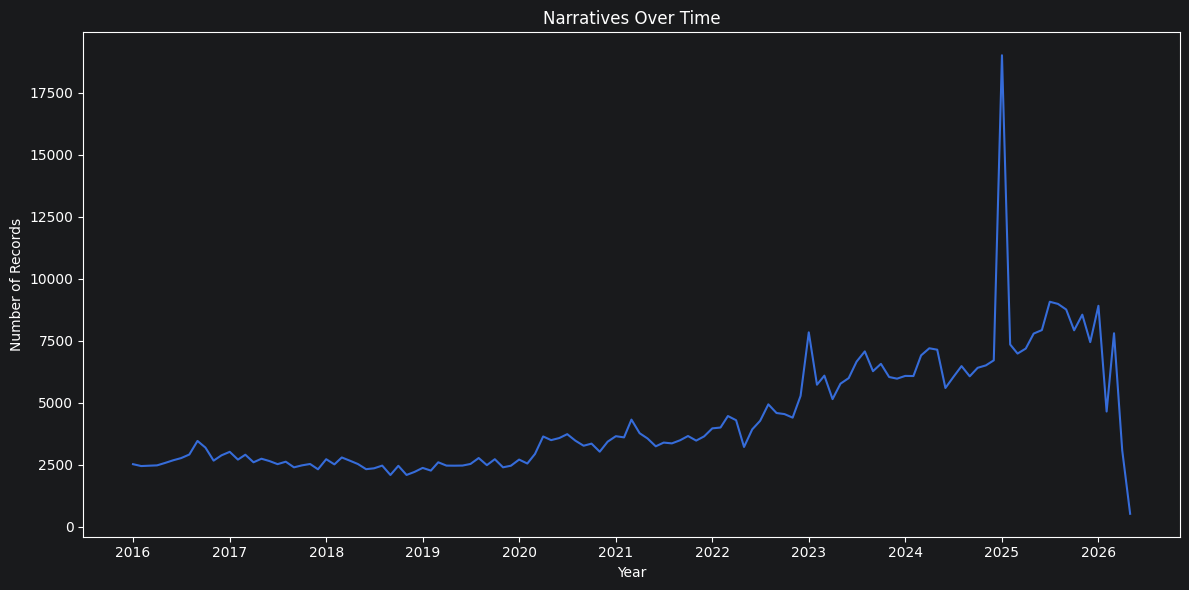

In [19]:
# Plot monthly totals over time
plt.figure(figsize=(12, 6))

plt.plot(
    complaints_by_month['month'],
    complaints_by_month['complaints']
)

ax = plt.gca()

# Show every year
ax.xaxis.set_major_locator(mdates.YearLocator())

# Format as 2020, 2021, etc.
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.title('Narratives Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Records')

plt.tight_layout()
plt.show()

In [20]:
# # Print sample of 10 narratives
# sample_narratives = (
#     df
#     .filter(pl.col('Consumer complaint narrative').is_not_null())
#     .select('Consumer complaint narrative')
#     .collect()
#     .sample(n=10, shuffle=True)
# )
#
# narratives = sample_narratives['Consumer complaint narrative'].to_list()
#
# for i, narrative in enumerate(narratives, start=1):
#     print(f'\n--- Narrative {i} ---')
#     print(narrative)

In [21]:
# Min/Max and Avg characters in the narratives
duckdb.sql(f"""
    SELECT
        MIN(LENGTH("Consumer complaint narrative")) AS min_chars,
        AVG(LENGTH("Consumer complaint narrative")) AS avg_chars,
        MAX(LENGTH("Consumer complaint narrative")) AS max_chars
    FROM '{PARQUET_PATH}'
    WHERE "Consumer complaint narrative" IS NOT NULL;
""")

┌───────────┬────────────────────┬───────────┐
│ min_chars │     avg_chars      │ max_chars │
│   int64   │       double       │   int64   │
├───────────┼────────────────────┼───────────┤
│         4 │ 1329.9457411583073 │     32785 │
└───────────┴────────────────────┴───────────┘

In [22]:
# Top 20 longest narratives with product and sub-product
duckdb.sql(f"""
    SELECT
        LENGTH("Consumer complaint narrative") AS chars,
        "Issue",
        "Sub-product"
    FROM '{PARQUET_PATH}'
    WHERE "Consumer complaint narrative" IS NOT NULL
    ORDER BY chars DESC
    LIMIT 20;
""")

┌───────┬─────────────────────────────────────────────────────────────────┬────────────────────────────────────────────┐
│ chars │                              Issue                              │                Sub-product                 │
│ int64 │                             varchar                             │                  varchar                   │
├───────┼─────────────────────────────────────────────────────────────────┼────────────────────────────────────────────┤
│ 32785 │ Advertising and marketing, including promotional offers         │ General-purpose credit card or charge card │
│ 32763 │ Closing your account                                            │ General-purpose credit card or charge card │
│ 32555 │ Closing your account                                            │ General-purpose credit card or charge card │
│ 32549 │ Closing your account                                            │ General-purpose credit card or charge card │
│ 32545 │ Closing your account  

In [23]:
# Narratives by issue
duckdb.sql(f"""
SELECT
    Issue,
    COUNT(*) AS narratives
FROM '{PARQUET_PATH}'
WHERE "Consumer complaint narrative" IS NOT NULL
GROUP BY Issue
ORDER BY narratives DESC;
""")

┌──────────────────────────────────────────────────────────────┬────────────┐
│                            Issue                             │ narratives │
│                           varchar                            │   int64    │
├──────────────────────────────────────────────────────────────┼────────────┤
│ Managing an account                                          │      97151 │
│ Trouble during payment process                               │      54832 │
│ Problem with a purchase shown on your statement              │      51762 │
│ Struggling to pay mortgage                                   │      26316 │
│ Closing an account                                           │      24742 │
│ Other features, terms, or problems                           │      24266 │
│ Fees or interest                                             │      22354 │
│ Problem with a lender or other company charging your account │      21915 │
│ Getting a credit card                                        │

In [24]:
# Avg narrative length by issue
duckdb.sql(f"""
    SELECT
        Issue,
        AVG(LENGTH("Consumer complaint narrative")) AS avg_chars
    FROM '{PARQUET_PATH}'
    WHERE "Consumer complaint narrative" IS NOT NULL
    GROUP BY Issue
    ORDER BY avg_chars DESC;
""")

┌──────────────────────────────────────────────────────────────────────────────────┬────────────────────┐
│                                      Issue                                       │     avg_chars      │
│                                     varchar                                      │       double       │
├──────────────────────────────────────────────────────────────────────────────────┼────────────────────┤
│ Closing on a mortgage                                                            │ 1941.1920460986207 │
│ Struggling to pay mortgage                                                       │ 1925.5790773673812 │
│ Applying for a mortgage or refinancing an existing mortgage                      │ 1750.9236698499317 │
│ Trouble during payment process                                                   │ 1640.6124161073826 │
│ Loan modification,collection,foreclosure                                         │ 1586.9921089277425 │
│ Problem with a purchase shown on your statem

In [25]:
# Rough word count using simple pattern for words
word_counts = (
    df
    .filter(pl.col('Consumer complaint narrative').is_not_null())
    .select(
        (
            pl.col('Consumer complaint narrative')
            .str.count_matches(r'\s+') + 1
        ).alias('word_count')
    )
    .collect()
)

In [26]:
word_counts.describe()

statistic,word_count
str,f64
"""count""",541497.0
"""null_count""",0.0
"""mean""",238.136076
"""std""",256.588821
"""min""",1.0
"""25%""",89.0
"""50%""",172.0
"""75%""",297.0
"""max""",6469.0


In [27]:
# Median word_count
word_counts.select(
    pl.col('word_count').median()
)

word_count
f64
172.0


## Narrative EDA (Pandas)

In [28]:
# Convert word count to pandas dataframe
word_counts_pd = word_counts.to_pandas()

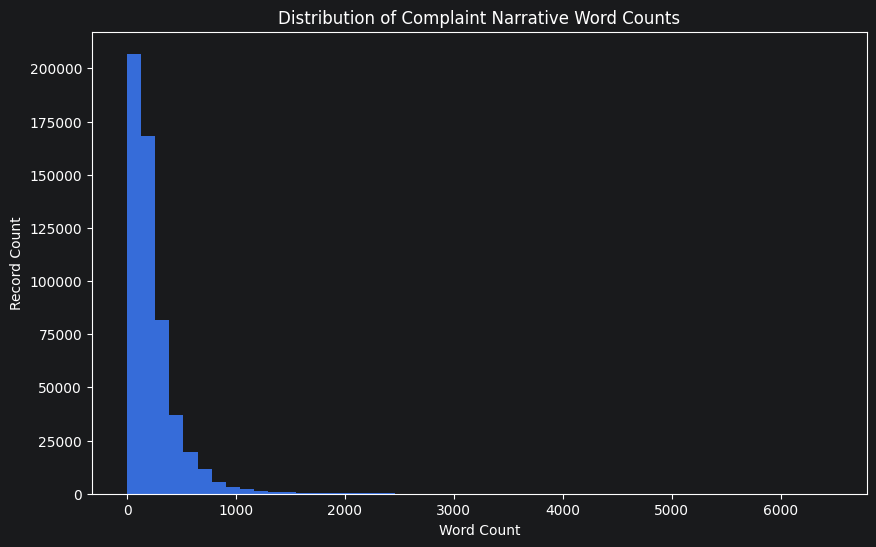

In [29]:
# Generate histogram of word counts
plt.figure(figsize=(10, 6))
plt.hist(word_counts_pd['word_count'], bins=50)

plt.title('Distribution of Complaint Narrative Word Counts')
plt.xlabel('Word Count')
plt.ylabel('Record Count')

plt.show()

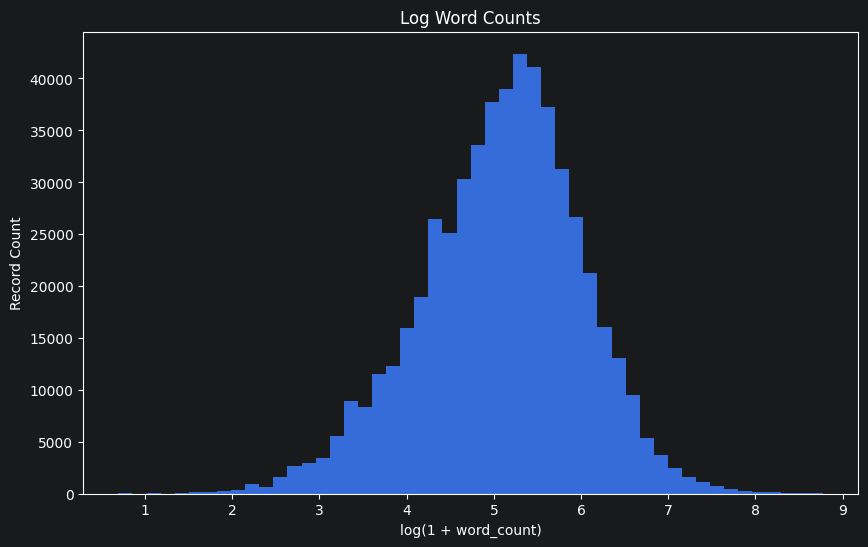

In [30]:
# Plot histogram with log transform
plt.figure(figsize=(10, 6))

plt.hist(
    np.log1p(word_counts_pd['word_count']),
    bins=50
)

plt.title('Log Word Counts')
plt.xlabel('log(1 + word_count)')
plt.ylabel('Record Count')

plt.show()

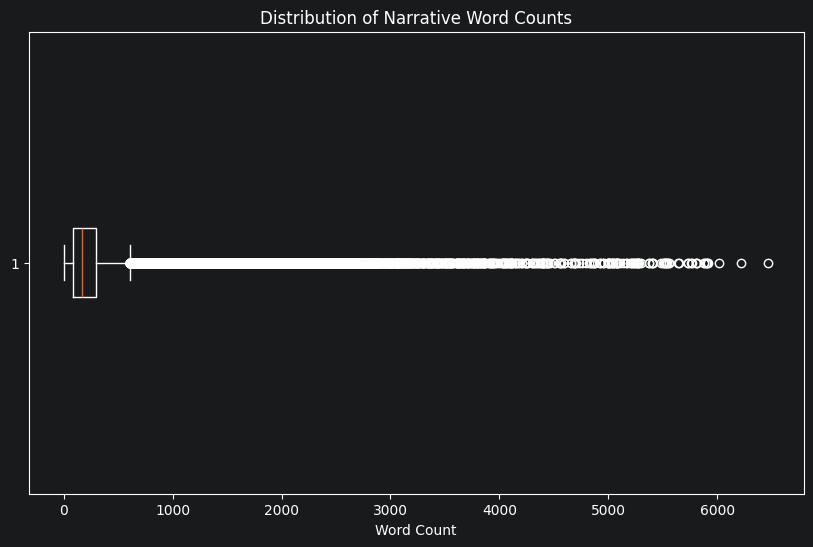

In [31]:
# Generate box plot of word counts
plt.figure(figsize=(10, 6))

plt.boxplot(
    word_counts_pd['word_count'],
    vert=False
)

plt.title('Distribution of Narrative Word Counts')
plt.xlabel('Word Count')

plt.show()

In [32]:
# Add word counts to the dataframe
df_with_counts = (
    df
    .filter(pl.col('Consumer complaint narrative').is_not_null())
    .with_columns(
        pl.col('Consumer complaint narrative')
        .str.extract_all(r'\b\w+\b')
        .list.len()
        .alias('word_count')
    )
    .collect()
    .to_pandas()
)

df_with_counts.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID,word_count
0,2019-11-18,Credit card or prepaid card,General-purpose credit card or charge card,Problem with a purchase shown on your statement,Credit card company isn't resolving a dispute ...,XXXX claimed they delivered a package to my ad...,NaN,DISCOVER BANK,MA,021XX,NaN,Consent provided,Web,2019-11-18,Closed with explanation,True,N/A,3442136,190
1,2020-04-10,Credit card or prepaid card,General-purpose prepaid card,Trouble using the card,Trouble getting information about the card,I got a Brinks Money pre-paid card in the mail...,Company has responded to the consumer and the ...,Netspend Corporation,IL,60657,NaN,Consent provided,Web,2020-04-14,Closed with explanation,True,N/A,3601853,45
2,2019-07-09,Credit card or prepaid card,Store credit card,Problem with a purchase shown on your statement,Card was charged for something you did not pur...,On XX/XX/XXXX I was called by a creditor Nelso...,NaN,Nelson Cruz & Associates LLC,TN,37043,NaN,Consent provided,Web,2019-07-09,Closed with explanation,True,N/A,3300820,165
3,2020-07-10,Credit card or prepaid card,General-purpose credit card or charge card,Trouble using your card,Can't use card to make purchases,Around XX/XX/2020 i XXXX XXXX XXXX opened a cr...,NaN,CAPITAL ONE FINANCIAL CORPORATION,CA,937XX,NaN,Consent provided,Web,2020-07-10,Closed with explanation,True,N/A,3739698,230
4,2020-04-23,Mortgage,Conventional home mortgage,Struggling to pay mortgage,NaN,Rushmore Loan management XXXX will not permit ...,NaN,RUSHMORE LOAN MANAGEMENT SERVICES LLC,AL,36117,NaN,Consent provided,Web,2020-04-27,Closed with explanation,True,N/A,3619130,106


In [33]:
df_with_counts.info()

<class 'pandas.DataFrame'>
RangeIndex: 541497 entries, 0 to 541496
Data columns (total 19 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   Date received                 541497 non-null  datetime64[ms]
 1   Product                       541497 non-null  str           
 2   Sub-product                   528868 non-null  str           
 3   Issue                         541497 non-null  str           
 4   Sub-issue                     422230 non-null  str           
 5   Consumer complaint narrative  541497 non-null  str           
 6   Company public response       266484 non-null  str           
 7   Company                       541497 non-null  str           
 8   State                         538905 non-null  str           
 9   ZIP code                      541497 non-null  str           
 10  Tags                          114209 non-null  str           
 11  Consumer consent provide

In [34]:
# Word counts by Product
df_with_counts['Product'].value_counts()

Product
Checking or savings account    178684
Mortgage                       130964
Credit card                    112860
Credit card or prepaid card    108665
Bank account or service         10324
Name: count, dtype: int64

In [35]:
# Calculate percentiles to get a better sense of long narratives
pd.DataFrame({
    'p90': [df_with_counts['word_count'].quantile(0.90)],
    'p95': [df_with_counts['word_count'].quantile(0.95)],
    'p99': [df_with_counts['word_count'].quantile(0.99)]
})

,p90,p95,p99
0,493.4,663.0,1210.0


In [36]:
# Review 20 longest narratives
longest_20 = (
    df_with_counts
    .sort_values('word_count', ascending=False)
    .loc[:, [
        'word_count',
        'Company',
        'Issue',
        'Sub-product',
        'Timely response?',
        'Consumer complaint narrative'
    ]]
    .head(20)
)

longest_20

,word_count,Company,Issue,Sub-product,Timely response?,Consumer complaint narrative
60753,6472,"CITIBANK, N.A.",Problem with a company's investigation into an...,General-purpose credit card or charge card,True,"On XXXX, a payment was made to my Citi bank ca..."
519040,6270,AMERICAN EXPRESS COMPANY,"Advertising and marketing, including promotion...",General-purpose credit card or charge card,True,I am due a referral bonus on the XXXX XXXX car...
296187,6224,OLD NATIONAL BANCORP,Managing an account,Checking account,True,b'I was born XXXX XXXX XXXX and was given in e...
387784,5958,ALLY FINANCIAL INC.,Managing an account,Checking account,True,I would like for the CFPB to reopen & review a...
186092,5917,Mr. Cooper Group Inc.,Trouble during payment process,FHA mortgage,True,i WAS NEVER ACCRIETED MY OVERPAYEMNST FORM BEI...
235107,5905,"Rocket Mortgage, LLC",Struggling to pay mortgage,Conventional home mortgage,True,TO THE CONSUMER PROTECTION AGENCY cfbp* FROM :...
189613,5830,UNITED SERVICES AUTOMOBILE ASSOCIATION,Closing an account,Checking account,True,"To Whom It May Concern, After marrying United ..."
388267,5797,"Shellpoint Partners, LLC",Trouble during payment process,VA mortgage,True,"b""Summary\n\nShellpoint / XXXX have created a..."
264443,5794,TD BANK US HOLDING COMPANY,Closing on a mortgage,Other type of mortgage,True,XXXX XXXX- We started shopping around for Cons...
342248,5750,"SUNTRUST BANKS, INC.",Managing an account,Checking account,True,We had several fraud claims filed starting XX/...


In [37]:
for i, row in longest_20.iterrows():
    print(f'\n--- Complaint {i} ---')
    print(f'Word count: {row["word_count"]}')
    print(f'Company: {row["Company"]}')
    print(f'Issue: {row["Issue"]}')
    print(f'Sub-product: {row["Sub-product"]}')
    print(f'Timely response?: {row["Timely response?"]}')
    print('\nNarrative:')
    print(row['Consumer complaint narrative'])


--- Complaint 60753 ---
Word count: 6472
Company: CITIBANK, N.A.
Issue: Problem with a company's investigation into an existing problem
Sub-product: General-purpose credit card or charge card
Timely response?: True

Narrative:
On XXXX, a payment was made to my Citi bank card for the amount of XXXX. While on the phone the automated voice on the phone advises the payment was non-reversible once it was made to my account. After the payment was made it showed that it was posted to my account. I thought since the recording said it was not reversable the payment was good. After that the scammer had me pay him for making the payment. He even made another payment on the account for XXXX and some change. The problem came up when the scammer reversed the payment to my Citi bank card. I wasnt notified that the payment was reversed, and no investigation was made on the reversed payment. When I called on XXXX I spoke with an agent named XXXX  employee ID: XXXX to get a copy of my statement showing

In [38]:
shortest_20 = (
    df_with_counts
    .sort_values('word_count', ascending=True)
    .loc[:, [
        'word_count',
        'Company',
        'Issue',
        'Sub-product',
        'Timely response?',
        'Consumer complaint narrative'
    ]]
    .head(20)
)

shortest_20

,word_count,Company,Issue,Sub-product,Timely response?,Consumer complaint narrative
120681,1,CAPITAL ONE FINANCIAL CORPORATION,"Other features, terms, or problems",General-purpose credit card or charge card,True,CapitalOneallowedadatabreachthatXXXXhavedistri...
531942,1,PNC Bank N.A.,Opening an account,Savings account,True,Okay
465411,2,WELLS FARGO & COMPANY,Problem with a lender or other company chargin...,Checking account,True,Overdraft charges
418885,2,"CITIBANK, N.A.",Credit monitoring or identity theft protection...,Store credit card,True,Unrecognizable charge
532311,2,DISCOVER BANK,Getting a credit card,General-purpose credit card or charge card,True,Denied credit
217025,2,"BANK OF AMERICA, NATIONAL ASSOCIATION",Managing an account,Checking account,True,see attachment
473270,2,"BANK OF AMERICA, NATIONAL ASSOCIATION",Opening an account,Savings account,True,XXXX XXXX &
461447,2,TRUIST FINANCIAL CORPORATION,Managing an account,Checking account,True,This week
213007,2,CAPITAL ONE FINANCIAL CORPORATION,Problem with a purchase shown on your statement,General-purpose credit card or charge card,True,See attached.
268676,2,"Bread Financial Holdings, Inc.",Customer service / Customer relations,NaN,True,"Threats, harassment"


In [39]:
shortest_20[['word_count', 'Consumer complaint narrative']]

,word_count,Consumer complaint narrative
120681,1,CapitalOneallowedadatabreachthatXXXXhavedistri...
531942,1,Okay
465411,2,Overdraft charges
418885,2,Unrecognizable charge
532311,2,Denied credit
217025,2,see attachment
473270,2,XXXX XXXX &
461447,2,This week
213007,2,See attached.
268676,2,"Threats, harassment"


In [40]:
# Number of records with word counts less than 10
(
    df_with_counts['word_count']
    .le(10)
    .sum()
)

np.int64(2348)

In [41]:
# Sort dataframe by word_count ascending
df_with_counts.sort_values(
    'word_count',
    ascending=True
).loc[:, [
        'word_count',
        'Company',
        'Issue',
        'Sub-product',
        'Timely response?',
        'Consumer complaint narrative'
    ]]

,word_count,Company,Issue,Sub-product,Timely response?,Consumer complaint narrative
120681,1,CAPITAL ONE FINANCIAL CORPORATION,"Other features, terms, or problems",General-purpose credit card or charge card,True,CapitalOneallowedadatabreachthatXXXXhavedistri...
531942,1,PNC Bank N.A.,Opening an account,Savings account,True,Okay
465411,2,WELLS FARGO & COMPANY,Problem with a lender or other company chargin...,Checking account,True,Overdraft charges
418885,2,"CITIBANK, N.A.",Credit monitoring or identity theft protection...,Store credit card,True,Unrecognizable charge
532311,2,DISCOVER BANK,Getting a credit card,General-purpose credit card or charge card,True,Denied credit
...,...,...,...,...,...,...
186092,5917,Mr. Cooper Group Inc.,Trouble during payment process,FHA mortgage,True,i WAS NEVER ACCRIETED MY OVERPAYEMNST FORM BEI...
387784,5958,ALLY FINANCIAL INC.,Managing an account,Checking account,True,I would like for the CFPB to reopen & review a...
296187,6224,OLD NATIONAL BANCORP,Managing an account,Checking account,True,b'I was born XXXX XXXX XXXX and was given in e...
519040,6270,AMERICAN EXPRESS COMPANY,"Advertising and marketing, including promotion...",General-purpose credit card or charge card,True,I am due a referral bonus on the XXXX XXXX car...


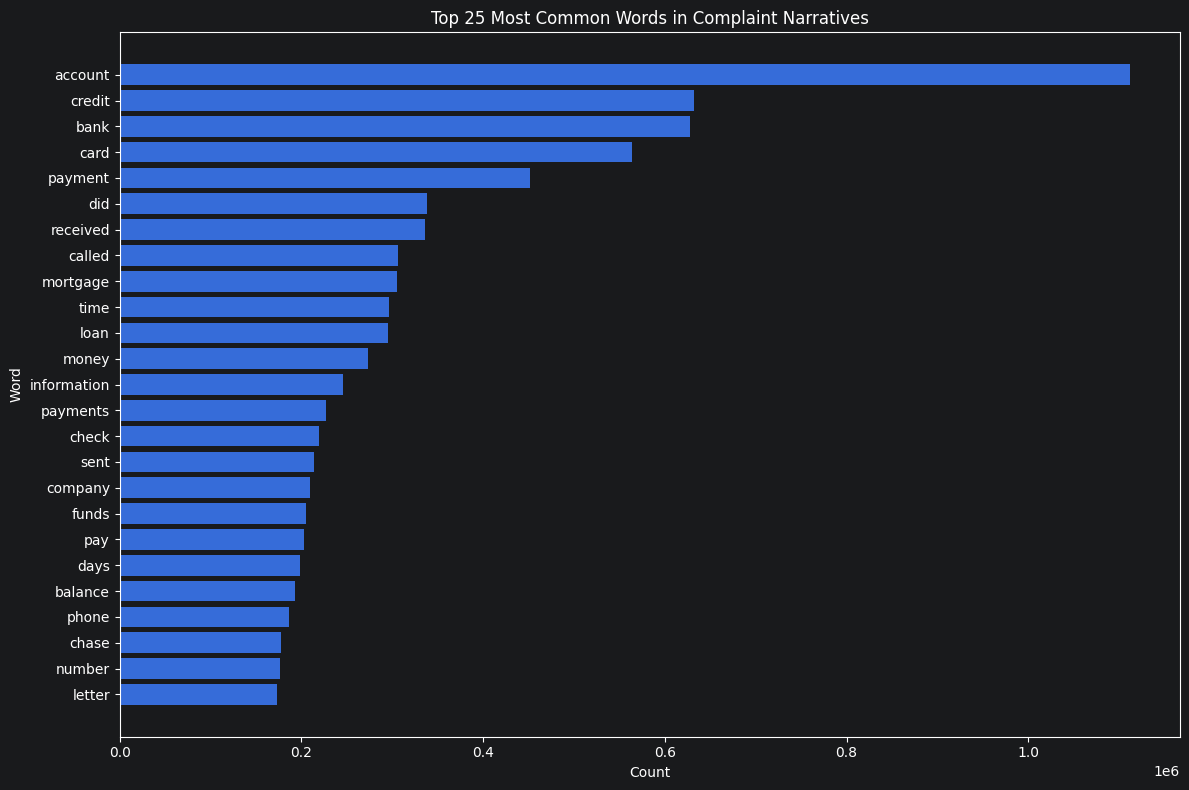

In [42]:
# Bar chart - top 25 words

# Stop words
custom_stop_words = set(ENGLISH_STOP_WORDS).union({
    'xxxx',
    'xx',
    'xxxxxxxx',
    'said',
    'told'
})

# Count words across all narratives
word_counter = Counter()

for text in df_with_counts['Consumer complaint narrative'].dropna():

    tokens = re.findall(
        r'\b[a-z]{2,}\b',
        str(text).lower()
    )

    tokens = [
        token for token in tokens
        if token not in custom_stop_words
    ]

    word_counter.update(tokens)

# Top 25 words
top_25_words = word_counter.most_common(25)

top_words_df = pd.DataFrame(
    top_25_words,
    columns=['word', 'count']
)

# Plot
plt.figure(figsize=(12, 8))

plt.barh(
    top_words_df['word'][::-1],
    top_words_df['count'][::-1]
)

plt.title('Top 25 Most Common Words in Complaint Narratives')
plt.xlabel('Count')
plt.ylabel('Word')

plt.tight_layout()
plt.show()

## Check for Duplicates

In [43]:
# Check for duplicate Complaint ID
duplicate_row_count = df_with_counts['Complaint ID'].duplicated(keep=False).sum()
duplicate_row_count

np.int64(0)

In [44]:
# Check for duplicate narratives
duplicate_row_count = df_with_counts['Consumer complaint narrative'].duplicated(keep=False).sum()
duplicate_row_count

np.int64(20540)

In [45]:
# Inspect the rows
duplicate_rows_df = (
    df_with_counts
    .loc[df_with_counts['Consumer complaint narrative'].duplicated(keep=False)]
    .sort_values('Consumer complaint narrative')
)

duplicate_rows_df

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID,word_count
129918,2023-11-20,Credit card,General-purpose credit card or charge card,Trouble using your card,Can't use card to make purchases,. Billing Error amount of {$2400.00}. One of t...,Company has responded to the consumer and the ...,"CITIBANK, N.A.",NJ,07111,NaN,Consent provided,Web,2023-12-05,Closed with explanation,True,N/A,7878793,92
176445,2023-11-20,Credit card,General-purpose credit card or charge card,Trouble using your card,Can't use card to make purchases,. Billing Error amount of {$2400.00}. One of t...,Company has responded to the consumer and the ...,"CITIBANK, N.A.",NJ,07111,NaN,Consent provided,Web,2023-11-20,Closed with explanation,True,N/A,7879166,92
64806,2023-07-18,Credit card or prepaid card,General-purpose credit card or charge card,Problem with a credit reporting company's inve...,Was not notified of investigation status or re...,. See the attached documents. I want the burea...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",IL,60651,NaN,Consent provided,Web,2023-07-18,Closed with non-monetary relief,True,N/A,7276305,28
66887,2023-07-17,Credit card or prepaid card,General-purpose credit card or charge card,Problem with a credit reporting company's inve...,Was not notified of investigation status or re...,. See the attached documents. I want the burea...,NaN,"EQUIFAX, INC.",TX,782XX,NaN,Consent provided,Web,2023-07-17,Closed with non-monetary relief,True,N/A,7261543,28
100060,2023-10-05,Credit card,General-purpose credit card or charge card,Problem with a company's investigation into an...,Was not notified of investigation status or re...,. See the attached documents. I want the burea...,NaN,"EQUIFAX, INC.",IL,60517,NaN,Consent provided,Web,2023-10-05,Closed with non-monetary relief,True,N/A,7642120,28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245450,2024-03-28,Checking or savings account,Checking account,Opening an account,Unable to open an account,unable to open checking account,NaN,JPMORGAN CHASE & CO.,OH,45044,NaN,Consent provided,Web,2024-03-28,Closed with explanation,True,N/A,8649767,5
151280,2020-11-15,Credit card or prepaid card,General-purpose credit card or charge card,Problem with a purchase shown on your statement,Card was charged for something you did not pur...,unauthorized online purchase was made resultin...,Company has responded to the consumer and the ...,SYNCHRONY FINANCIAL,CA,91770,NaN,Consent provided,Web,2020-11-15,Closed with explanation,True,N/A,3955163,127
282443,2020-11-15,Credit card or prepaid card,General-purpose credit card or charge card,Problem with a purchase shown on your statement,Card was charged for something you did not pur...,unauthorized online purchase was made resultin...,NaN,JPMORGAN CHASE & CO.,CA,91770,NaN,Consent provided,Web,2020-11-15,Closed with explanation,True,N/A,3955162,127
26035,2020-11-19,Checking or savings account,CD (Certificate of Deposit),Closing an account,Funds not received from closed account,under cares act this retirement account was al...,Company has responded to the consumer and the ...,ALLY FINANCIAL INC.,CA,XXXXX,Servicemember,Consent provided,Web,2020-11-19,Closed with explanation,True,N/A,3962772,55


In [46]:
# Group by complaint narrative and count distinct company responses
duplicate_responses = (
    df_with_counts
    .groupby('Consumer complaint narrative')['Company response to consumer']
    .nunique()
    .reset_index(name='num_unique_responses')
)

# Keep narratives that have more than one distinct response
duplicate_responses = duplicate_responses[
    duplicate_responses['num_unique_responses'] > 1
]

print(f'Found {len(duplicate_responses):,} unique narratives that have duplicates with different company responses.')
duplicate_responses.head()

Found 1,271 unique narratives that have duplicates with different company responses.


,Consumer complaint narrative,num_unique_responses
1551,. See the attached documents. I want the burea...,2
2881,1.I have never had an account with this compan...,2
2893,1.I have never had an account with this compan...,2
3048,15 USC 1692-c If a consumer notifies a debt co...,2
4342,A account was open without my consent in is st...,2


In [47]:
# Inspect first 20 rows of unique duplicates with different company responses
conflicting_narratives = duplicate_responses['Consumer complaint narrative']

conflicting_records = (
    df_with_counts[
        df_with_counts['Consumer complaint narrative'].isin(conflicting_narratives)
    ]
    .sort_values(
        [
            'Consumer complaint narrative',
            'Company response to consumer'
        ]
    )
)

print(f'Conflicting records: {len(conflicting_records):,}')

conflicting_records[
    [
        'Complaint ID',
        'Consumer complaint narrative',
        'Company response to consumer'
    ]
].head(20)

Conflicting records: 17,238


,Complaint ID,Consumer complaint narrative,Company response to consumer
428610,7642010,. See the attached documents. I want the burea...,Closed with explanation
64806,7276305,. See the attached documents. I want the burea...,Closed with non-monetary relief
66887,7261543,. See the attached documents. I want the burea...,Closed with non-monetary relief
100060,7642120,. See the attached documents. I want the burea...,Closed with non-monetary relief
119243,7642122,. See the attached documents. I want the burea...,Closed with non-monetary relief
446940,7261913,. See the attached documents. I want the burea...,Closed with non-monetary relief
50285,6753972,1.I have never had an account with this compan...,Closed with explanation
429456,6705274,1.I have never had an account with this compan...,Closed with non-monetary relief
220624,6698084,1.I have never had an account with this compan...,Closed with explanation
58771,6543326,1.I have never had an account with this compan...,Closed with non-monetary relief


In [48]:
# Check for duplicates that have conflicting responses between monetary and the bucket of non-monetary outcomes
duckdb.sql(f"""
WITH bucketed AS (
    SELECT
        "Consumer complaint narrative",
        CASE
            WHEN "Company response to consumer" = 'Closed with monetary relief'
                THEN 'Monetary relief'
            WHEN "Company response to consumer" IN (
                'Closed with explanation',
                'Closed with non-monetary relief',
                'Closed'
            )
                THEN 'Non-monetary / explanation / closed'
        END AS response_bucket
    FROM '{PARQUET_PATH}'
    WHERE "Consumer complaint narrative" IS NOT NULL
      AND TRIM("Consumer complaint narrative") <> ''
      AND "Company response to consumer" IN (
          'Closed with monetary relief',
          'Closed with explanation',
          'Closed with non-monetary relief',
          'Closed'
      )
),

conflicting_narratives AS (
    SELECT
        "Consumer complaint narrative"
    FROM bucketed
    GROUP BY "Consumer complaint narrative"
    HAVING COUNT(DISTINCT response_bucket) > 1
)

SELECT
    COUNT(*) AS conflicting_records,
    COUNT(DISTINCT "Consumer complaint narrative") AS conflicting_unique_narratives
FROM bucketed
WHERE "Consumer complaint narrative" IN (
    SELECT "Consumer complaint narrative"
    FROM conflicting_narratives
)
""")

┌─────────────────────┬───────────────────────────────┐
│ conflicting_records │ conflicting_unique_narratives │
│        int64        │             int64             │
├─────────────────────┼───────────────────────────────┤
│                3121 │                            61 │
└─────────────────────┴───────────────────────────────┘

In [49]:
# Inspect examples
duckdb.sql(f"""
WITH bucketed AS (
    SELECT
        "Complaint ID",
        "Consumer complaint narrative",
        "Company response to consumer",
        CASE
            WHEN "Company response to consumer" = 'Closed with monetary relief'
                THEN 'Monetary relief'
            WHEN "Company response to consumer" IN (
                'Closed with explanation',
                'Closed with non-monetary relief',
                'Closed'
            )
                THEN 'Non-monetary / explanation / closed'
        END AS response_bucket
    FROM '{PARQUET_PATH}'
    WHERE "Consumer complaint narrative" IS NOT NULL
      AND TRIM("Consumer complaint narrative") <> ''
      AND "Company response to consumer" IN (
          'Closed with monetary relief',
          'Closed with explanation',
          'Closed with non-monetary relief',
          'Closed'
      )
),

conflicting_narratives AS (
    SELECT
        "Consumer complaint narrative"
    FROM bucketed
    GROUP BY "Consumer complaint narrative"
    HAVING COUNT(DISTINCT response_bucket) > 1
)

SELECT
    "Complaint ID",
    "Company response to consumer",
    response_bucket,
    "Consumer complaint narrative"
FROM bucketed
WHERE "Consumer complaint narrative" IN (
    SELECT "Consumer complaint narrative"
    FROM conflicting_narratives
)
ORDER BY "Consumer complaint narrative", response_bucket
LIMIT 20
""")

┌──────────────┬──────────────────────────────┬─────────────────────────────────────┬───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Complaint ID │ Company response to consumer │           response_bucket           │                                                                                                                                                                                                         Consumer complaint narrative                                                                                                                                                                        

In [57]:
# Calculate exact duplicates on narrative AND company response
exact_duplicate_count = df_with_counts.duplicated(
    subset=[
        'Consumer complaint narrative',
        'Company response to consumer'
    ]
).sum()

print(f'Exact duplicate rows: {exact_duplicate_count:,}')

Exact duplicate rows: 16,868


In [59]:
# Inspect first 20 rows of exact duplicates on narrative AND company response
exact_duplicates = (
    df_with_counts[
        df_with_counts.duplicated(
            subset=[
                'Consumer complaint narrative',
                'Company response to consumer'
            ],
            keep=False
        )
    ]
    .sort_values(
        [
            'Consumer complaint narrative',
            'Company response to consumer'
        ]
    )
)

exact_duplicates.head(20)

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID,word_count
129918,2023-11-20,Credit card,General-purpose credit card or charge card,Trouble using your card,Can't use card to make purchases,. Billing Error amount of {$2400.00}. One of t...,Company has responded to the consumer and the ...,"CITIBANK, N.A.",NJ,07111,NaN,Consent provided,Web,2023-12-05,Closed with explanation,True,N/A,7878793,92
176445,2023-11-20,Credit card,General-purpose credit card or charge card,Trouble using your card,Can't use card to make purchases,. Billing Error amount of {$2400.00}. One of t...,Company has responded to the consumer and the ...,"CITIBANK, N.A.",NJ,07111,NaN,Consent provided,Web,2023-11-20,Closed with explanation,True,N/A,7879166,92
64806,2023-07-18,Credit card or prepaid card,General-purpose credit card or charge card,Problem with a credit reporting company's inve...,Was not notified of investigation status or re...,. See the attached documents. I want the burea...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",IL,60651,NaN,Consent provided,Web,2023-07-18,Closed with non-monetary relief,True,N/A,7276305,28
66887,2023-07-17,Credit card or prepaid card,General-purpose credit card or charge card,Problem with a credit reporting company's inve...,Was not notified of investigation status or re...,. See the attached documents. I want the burea...,NaN,"EQUIFAX, INC.",TX,782XX,NaN,Consent provided,Web,2023-07-17,Closed with non-monetary relief,True,N/A,7261543,28
100060,2023-10-05,Credit card,General-purpose credit card or charge card,Problem with a company's investigation into an...,Was not notified of investigation status or re...,. See the attached documents. I want the burea...,NaN,"EQUIFAX, INC.",IL,60517,NaN,Consent provided,Web,2023-10-05,Closed with non-monetary relief,True,N/A,7642120,28
119243,2023-10-05,Credit card,General-purpose credit card or charge card,Problem with a company's investigation into an...,Was not notified of investigation status or re...,. See the attached documents. I want the burea...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",IL,60517,NaN,Consent provided,Web,2023-10-05,Closed with non-monetary relief,True,N/A,7642122,28
446940,2023-07-17,Credit card or prepaid card,General-purpose credit card or charge card,Problem with a credit reporting company's inve...,Was not notified of investigation status or re...,. See the attached documents. I want the burea...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",TX,782XX,NaN,Consent provided,Web,2023-07-17,Closed with non-monetary relief,True,N/A,7261913,28
128948,2020-08-07,Checking or savings account,Checking account,Opening an account,Didn't receive terms that were advertised,1. Opened a premium checking bundle as adverti...,NaN,"FIRST CITIZENS BANCSHARES, INC.",AZ,85027,NaN,Consent provided,Web,2020-08-07,Closed with monetary relief,True,N/A,3784360,120
311984,2020-08-21,Checking or savings account,Other banking product or service,Opening an account,Didn't receive terms that were advertised,1. Opened a premium checking bundle as adverti...,NaN,"FIRST CITIZENS BANCSHARES, INC.",AZ,85027,NaN,Consent provided,Web,2020-08-21,Closed with monetary relief,True,N/A,3807532,120
313598,2023-06-09,Credit card or prepaid card,General-purpose credit card or charge card,Getting a credit card,Card opened as result of identity theft or fraud,15 U.S. Code $ 1681c-2 a consumer reporting ag...,NaN,"Bread Financial Holdings, Inc.",PA,150XX,NaN,Consent provided,Web,2023-06-09,Closed with explanation,True,N/A,7095929,179
